In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.lines import Line2D
from nuscenes.nuscenes import NuScenes
from nuscenes.utils.data_classes import LidarPointCloud, Box
from pyquaternion import Quaternion

# Optional fallback paths (used only if `data` / `data_root` are not already defined).
pkl_path = '/home/mingdayang/mmdetection3d/data/nuscenes/mmdet3d_bevformer/nuscenes_annotation_files_custom/sampled_quarter_nuscenes_infos_temporal_train_pseudo_thr0p4.pkl'
default_data_root = '/home/mingdayang/mmdetection3d/data/nuscenes/'

if 'data' not in globals():
    with open(pkl_path, 'rb') as f:
        data = pickle.load(f)

if 'data_root' not in globals():
    data_root = default_data_root

if 'nusc' not in globals():
    nusc = NuScenes(version='v1.0-trainval', dataroot=data_root, verbose=True)

def get_info_list(annotation_data):
    if 'infos' in annotation_data:
        return annotation_data['infos']
    if 'data_list' in annotation_data:
        return annotation_data['data_list']
    raise KeyError("Expected key 'infos' or 'data_list' in pickle.")

def resolve_lidar_path(info, root):
    lidar_path = None
    if 'lidar_path' in info:
        lidar_path = info['lidar_path']
    elif 'lidar_points' in info and isinstance(info['lidar_points'], dict):
        lidar_path = info['lidar_points'].get('lidar_path')

    if lidar_path is None:
        raise KeyError("Could not find lidar path in sample info.")

    root = Path(root)
    raw = Path(str(lidar_path))
    raw_str = str(raw).replace('\\', '/')
    candidates = []

    if raw.is_absolute():
        candidates.append(raw)
    else:
        candidates.append(raw)
        candidates.append(root / raw)

    normalized = raw_str.lstrip('/')
    candidates.append(root / normalized)

    if 'data/nuscenes/' in normalized:
        suffix = normalized.split('data/nuscenes/', 1)[1]
        candidates.append(root / suffix)

    for prefix in ('samples/', 'sweeps/', 'maps/', 'v1.0-trainval/', 'v1.0-test/'):
        idx = normalized.find(prefix)
        if idx != -1:
            candidates.append(root / normalized[idx:])

    seen = set()
    unique_candidates = []
    for c in candidates:
        s = str(c)
        if s not in seen:
            unique_candidates.append(c)
            seen.add(s)

    for c in unique_candidates:
        if c.exists():
            return str(c)

    tried = '\n'.join(str(c) for c in unique_candidates[:8])
    raise FileNotFoundError(
        f'Could not resolve lidar file for token {info.get("token", "N/A")}. Tried:\n{tried}'
    )

def bev_corners_from_box7(box7):
    x, y, _, dx, dy, _, yaw = box7
    local = np.array([
        [ dx / 2,  dy / 2],
        [ dx / 2, -dy / 2],
        [-dx / 2, -dy / 2],
        [-dx / 2,  dy / 2],
    ], dtype=np.float32)
    cos_yaw = np.cos(yaw)
    sin_yaw = np.sin(yaw)
    rot = np.array([[cos_yaw, -sin_yaw], [sin_yaw, cos_yaw]], dtype=np.float32)
    corners = local @ rot.T
    corners += np.array([x, y], dtype=np.float32)
    return corners

def get_nuscenes_gt_boxes_lidar7(sample_token, nusc_obj):
    sample = nusc_obj.get('sample', sample_token)
    lidar_sd = nusc_obj.get('sample_data', sample['data']['LIDAR_TOP'])
    ego_pose = nusc_obj.get('ego_pose', lidar_sd['ego_pose_token'])
    calib = nusc_obj.get('calibrated_sensor', lidar_sd['calibrated_sensor_token'])

    gt_lidar_boxes = []
    for ann_token in sample['anns']:
        ann = nusc_obj.get('sample_annotation', ann_token)
        box = Box(
            center=np.asarray(ann['translation'], dtype=np.float32),
            size=np.asarray(ann['size'], dtype=np.float32),
            orientation=Quaternion(ann['rotation']),
            name=ann.get('category_name', ''),
        )

        # Global -> ego -> lidar
        box.translate(-np.asarray(ego_pose['translation'], dtype=np.float32))
        box.rotate(Quaternion(ego_pose['rotation']).inverse)
        box.translate(-np.asarray(calib['translation'], dtype=np.float32))
        box.rotate(Quaternion(calib['rotation']).inverse)

        center = box.center.astype(np.float32)
        size = box.wlh.astype(np.float32)
        yaw = float(box.orientation.yaw_pitch_roll[0])
        lidar_box7 = np.array(
            [center[0], center[1], center[2], size[0], size[1], size[2], -yaw - np.pi / 2],
            dtype=np.float32,
        )
        gt_lidar_boxes.append(lidar_box7)

    if len(gt_lidar_boxes) == 0:
        return np.zeros((0, 7), dtype=np.float32)
    return np.asarray(gt_lidar_boxes, dtype=np.float32)

def visualize_gt_bev(
    annotation_data,
    info_idx=0,
    point_size=0.15,
    max_points=30000,
    eval_range=50.0,
    draw_labels=False,
    random_seed=0,
):
    infos = get_info_list(annotation_data)
    if info_idx < 0 or info_idx >= len(infos):
        raise IndexError(f'info_idx={info_idx} out of range [0, {len(infos)-1}]')

    info = infos[info_idx]
    sample_token = info.get('token')
    if sample_token is None:
        raise KeyError('Sample info does not contain token.')

    lidar_file = resolve_lidar_path(info, data_root)
    pc = LidarPointCloud.from_file(lidar_file)
    pts_xy = pc.points[:2, :].T

    # Match official nuScenes detection visualization framing style.
    axes_limit = float(eval_range) + 3.0

    in_view = (
        (np.abs(pts_xy[:, 0]) <= axes_limit)
        & (np.abs(pts_xy[:, 1]) <= axes_limit)
    )
    pts_xy = pts_xy[in_view]

    if pts_xy.shape[0] > max_points:
        rng = np.random.default_rng(random_seed)
        pick = rng.choice(pts_xy.shape[0], size=max_points, replace=False)
        pts_xy = pts_xy[pick]

    # New boxes from your custom pickle.
    custom_boxes = np.asarray(info.get('gt_boxes', np.zeros((0, 7), dtype=np.float32)), dtype=np.float32)
    custom_names = info.get('gt_names', [])

    # Original nuScenes GT boxes for the same sample token.
    original_boxes = get_nuscenes_gt_boxes_lidar7(sample_token, nusc)

    fig, ax = plt.subplots(1, 1, figsize=(9, 9))
    ax.scatter(pts_xy[:, 0], pts_xy[:, 1], s=point_size, c='gray', alpha=0.6)
    ax.plot(0, 0, 'rx', markersize=8)

    # Custom pseudo/new boxes in purple.
    for i, box7 in enumerate(custom_boxes):
        corners = bev_corners_from_box7(box7)
        corners_closed = np.vstack([corners, corners[0]])
        ax.plot(corners_closed[:, 0], corners_closed[:, 1], color='green', linewidth=1.6)
        if draw_labels and i < len(custom_names):
            ax.text(box7[0], box7[1], str(custom_names[i]), color='green', fontsize=8)

    # Original nuScenes GT boxes in blue.
    for box7 in original_boxes:
        corners = bev_corners_from_box7(box7)
        corners_closed = np.vstack([corners, corners[0]])
        ax.plot(corners_closed[:, 0], corners_closed[:, 1], color='blue', linewidth=1.3)

    ax.set_title(
        f'BEV LiDAR | idx={info_idx} | token={sample_token} | '
        f'custom={len(custom_boxes)} | nuscenes_gt={len(original_boxes)} | points={len(pts_xy)}'
    )
    ax.set_xlabel('x (m)')
    ax.set_ylabel('y (m)')
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlim(-axes_limit, axes_limit)
    ax.set_ylim(-axes_limit, axes_limit)
    ax.grid(True, alpha=0.2)

    legend_handles = [
        Line2D([0], [0], color='green', lw=2, label='Custom boxes (new)'),
        Line2D([0], [0], color='blue', lw=2, label='nuScenes GT (original)'),
        Line2D([0], [0], color='red', marker='x', linestyle='None', markersize=8, label='LiDAR origin'),
    ]
    ax.legend(handles=legend_handles, loc='upper right')
    plt.tight_layout()
    plt.show()

# Example: change index to inspect different samples.


Loading NuScenes tables for version v1.0-trainval...
23 category,
8 attribute,
4 visibility,
64386 instance,
12 sensor,
10200 calibrated_sensor,
2631083 ego_pose,
68 log,
850 scene,
34149 sample,
2631083 sample_data,
1166187 sample_annotation,
4 map,
Done loading in 56.216 seconds.
Reverse indexing ...
Done reverse indexing in 19.1 seconds.


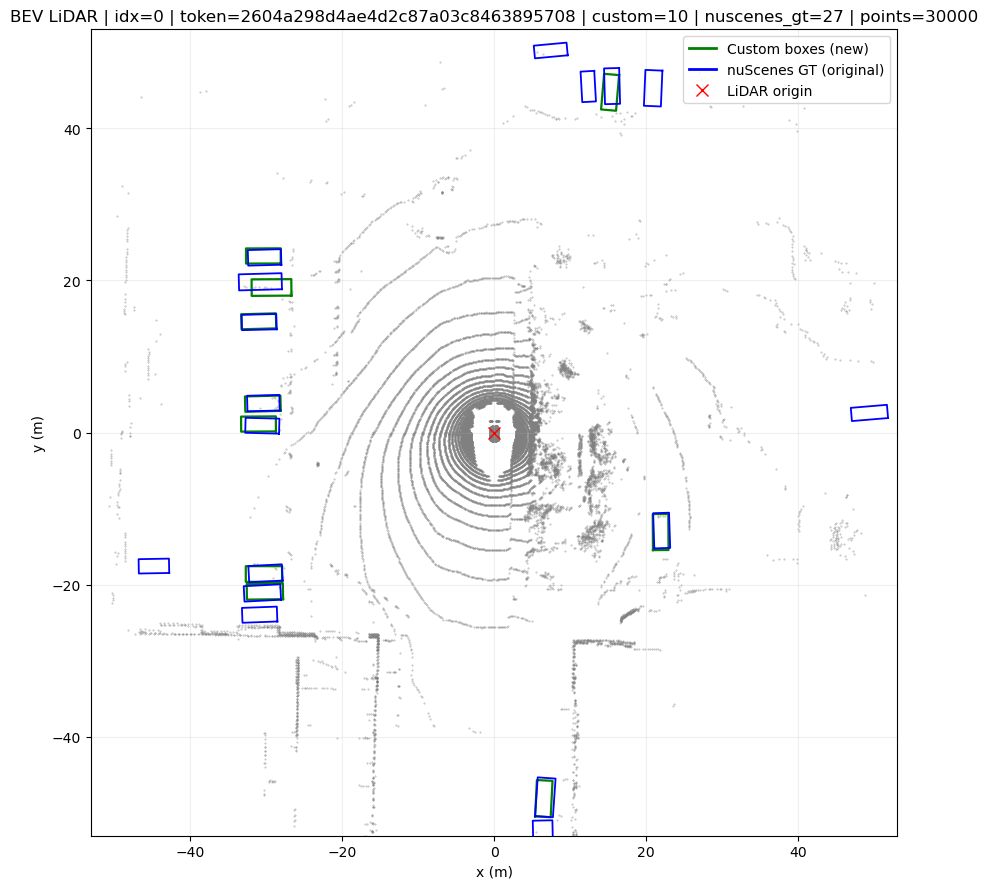

In [2]:
visualize_gt_bev(data, info_idx=0, eval_range=50.0, max_points=30000, draw_labels=False)

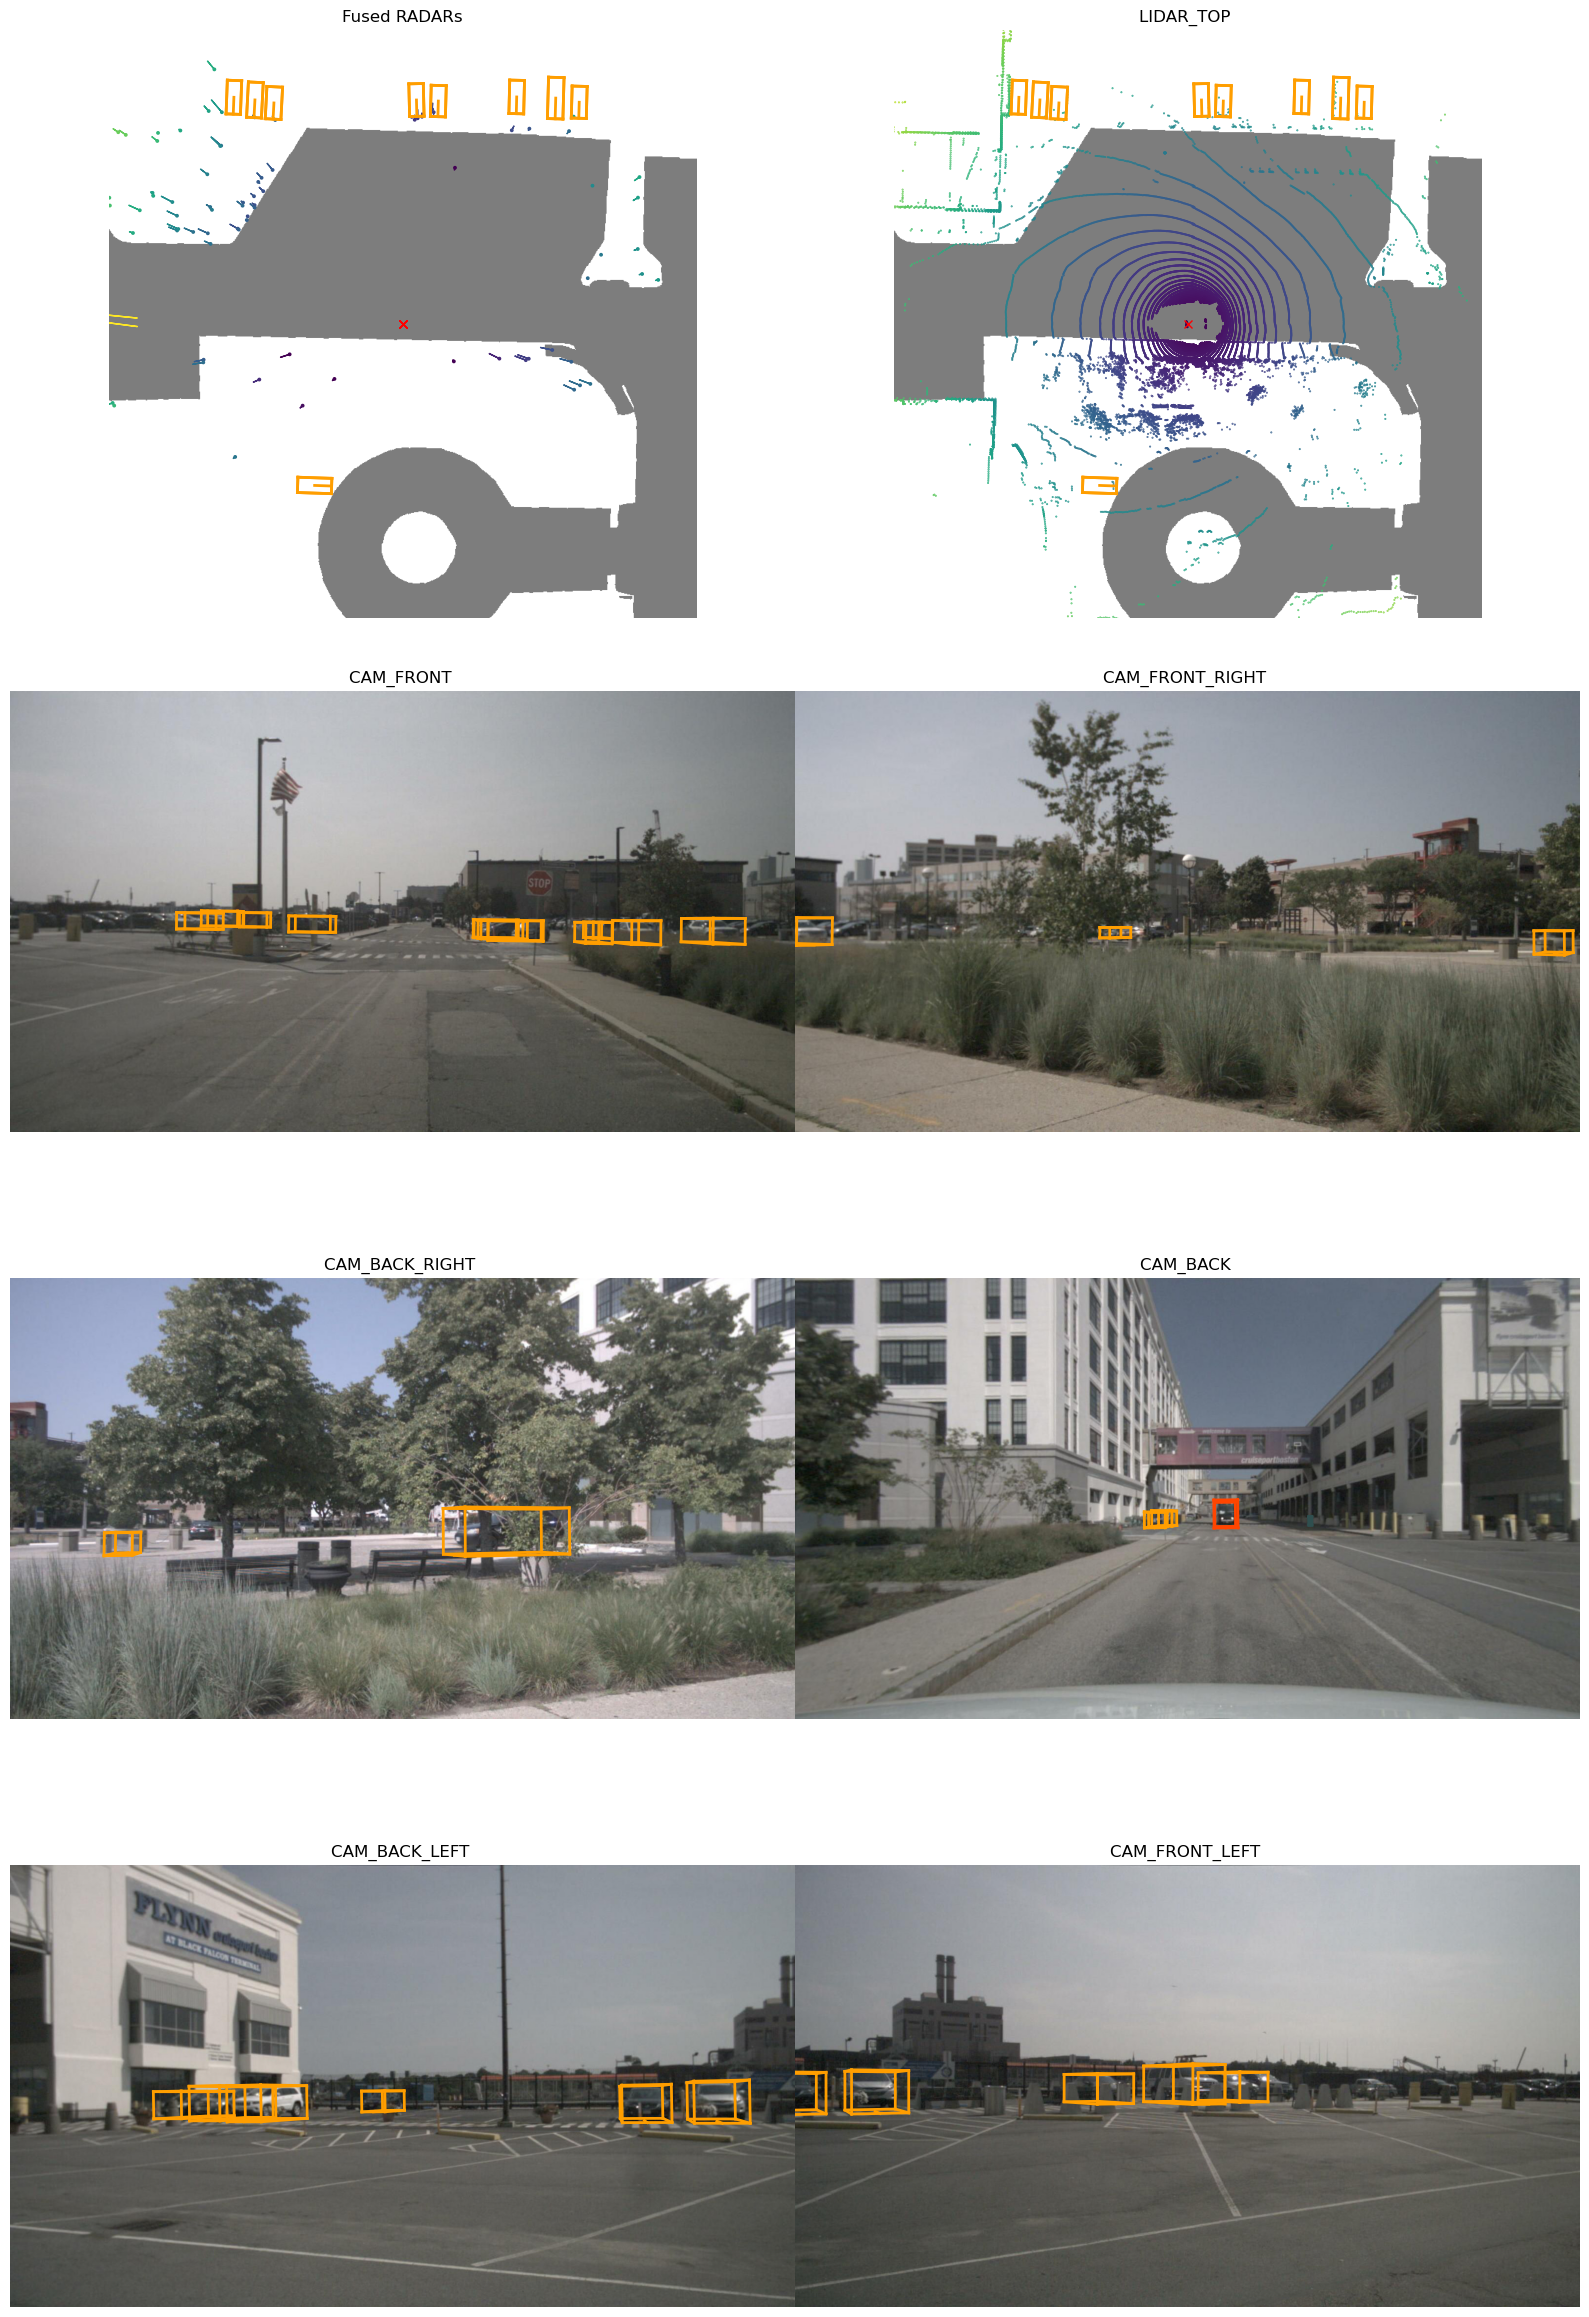

In [3]:
nusc.render_sample('2604a298d4ae4d2c87a03c8463895708')